In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
abc=pd.read_csv('/content/drive/MyDrive/Epileptic Seizure Recognition.csv')
abc

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


In [ ]:
X=abc.iloc[:,1:179].values
X.shape

(11500, 178)

Text(0.5, 0, 'Samples')

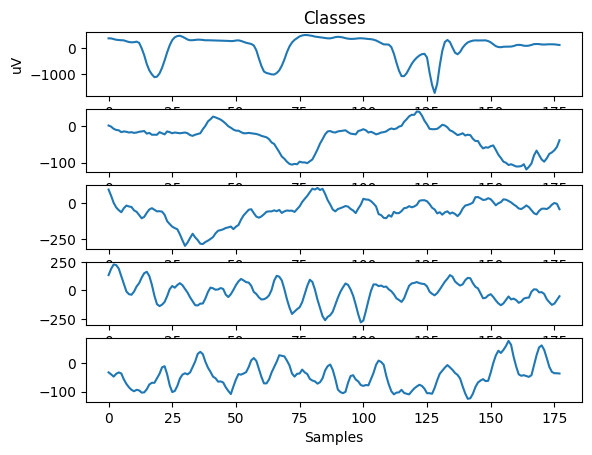

In [ ]:
plt.subplot(511)
plt.plot(X[1,:])
plt.title('Classes')
plt.ylabel('uV')
plt.subplot(512)
plt.plot(X[7,:])
plt.subplot(513)
plt.plot(X[12,:])
plt.subplot(514)
plt.plot(X[0,:])
plt.subplot(515)
plt.plot(X[2,:])
plt.xlabel('Samples')

In [ ]:
Y=abc.iloc[:,179].values
Y

array([4, 1, 5, ..., 5, 3, 4])

In [ ]:
Y[Y>1]=0
Y

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


82.74 %


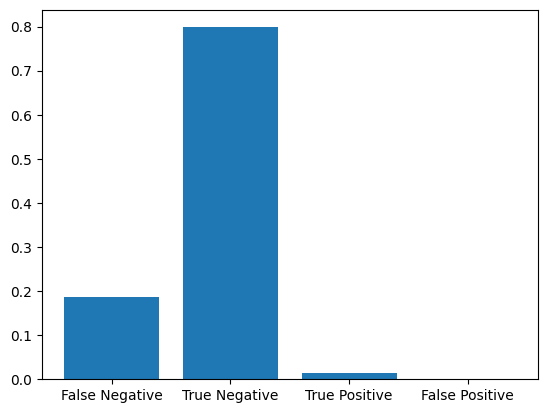

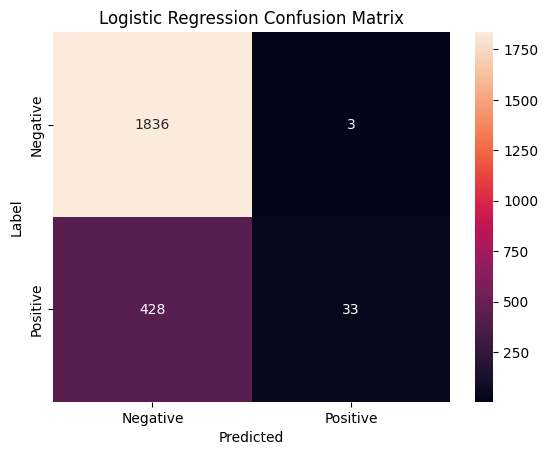

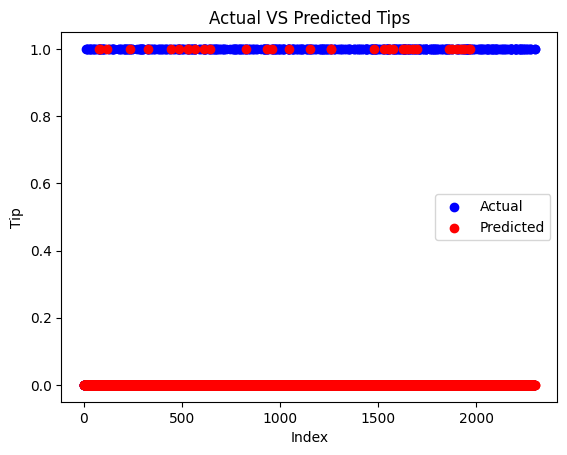

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1839
           1       0.92      0.07      0.13       461

    accuracy                           0.81      2300
   macro avg       0.86      0.53      0.51      2300
weighted avg       0.83      0.81      0.74      2300



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
clf = LogisticRegression()
clf.fit(X_train, Y_train)
y_pred_log_reg = clf.predict(X_test)
acc_log_reg = round(clf.score(X_train, Y_train) * 100, 2) #formula to calculate accuracy,2 means no. of values after decimal point
print (str(acc_log_reg) + ' %')
confusion = confusion_matrix(Y_test, y_pred_log_reg , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_log_reg)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_log_reg})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual')
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted')
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_log_reg))

94.15 %


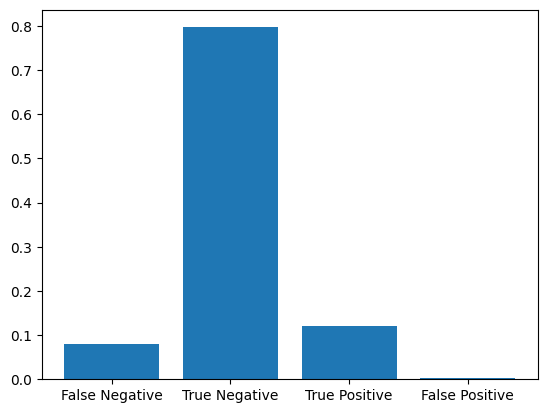

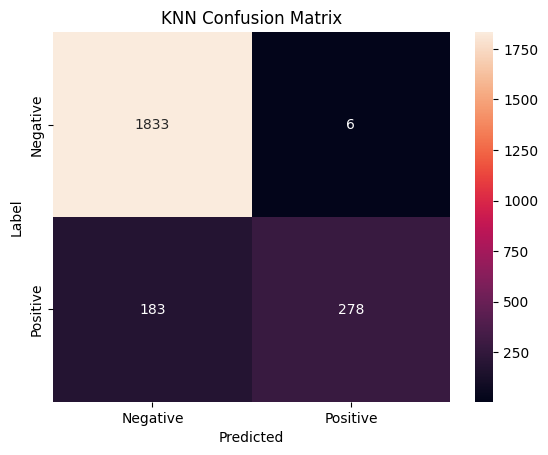

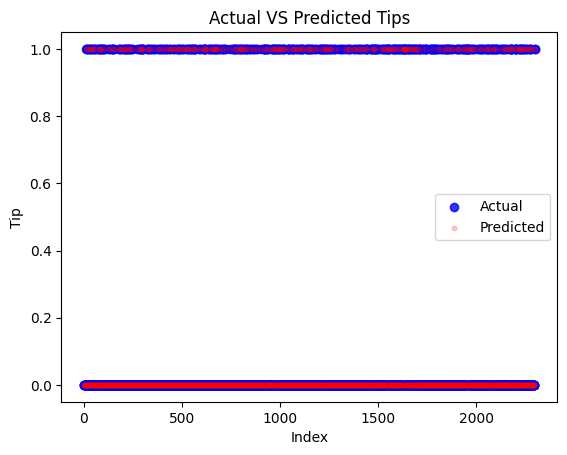

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1839
           1       0.98      0.60      0.75       461

    accuracy                           0.92      2300
   macro avg       0.94      0.80      0.85      2300
weighted avg       0.92      0.92      0.91      2300



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
clf = KNeighborsClassifier()
clf.fit(X_train, Y_train)
y_pred_knn = clf.predict(X_test)
acc_knn = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_knn) + ' %')
confusion = confusion_matrix(Y_test, y_pred_knn , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_knn)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("KNN Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_knn})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=10.5)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_knn))

95.88 %


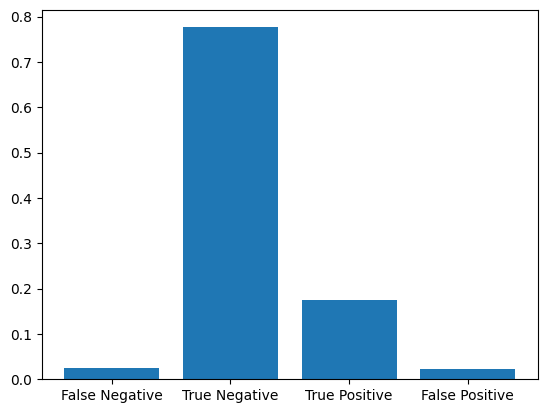

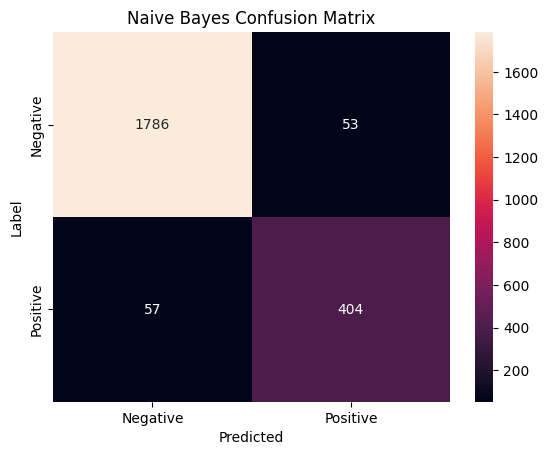

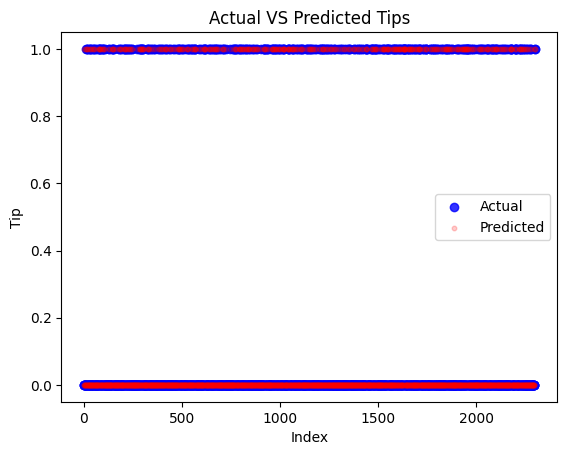

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1839
           1       0.88      0.88      0.88       461

    accuracy                           0.95      2300
   macro avg       0.93      0.92      0.93      2300
weighted avg       0.95      0.95      0.95      2300



In [ ]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X_train, Y_train)
y_pred_nb = clf.predict(X_test)
acc_nb = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_nb) + ' %')
confusion = confusion_matrix(Y_test, y_pred_nb , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_nb)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("Naive Bayes Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_nb})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=10.8)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_nb))

100.0 %


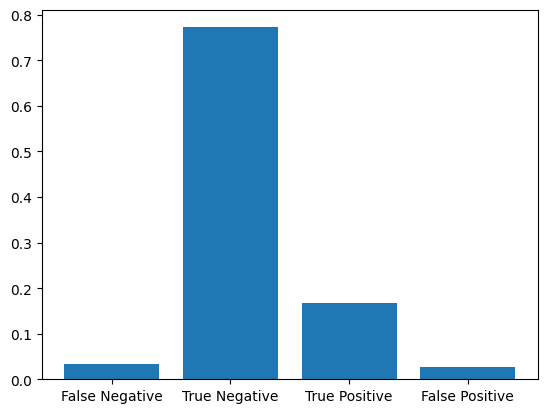

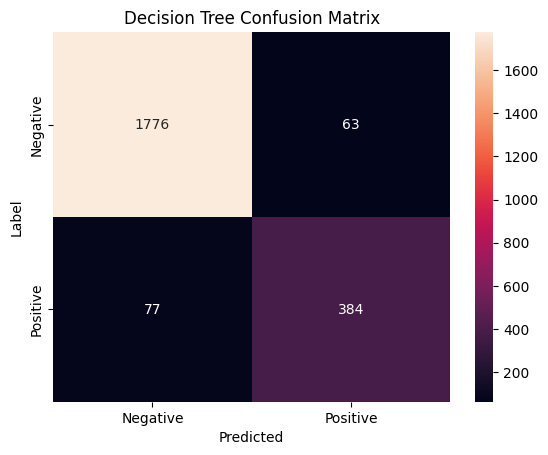

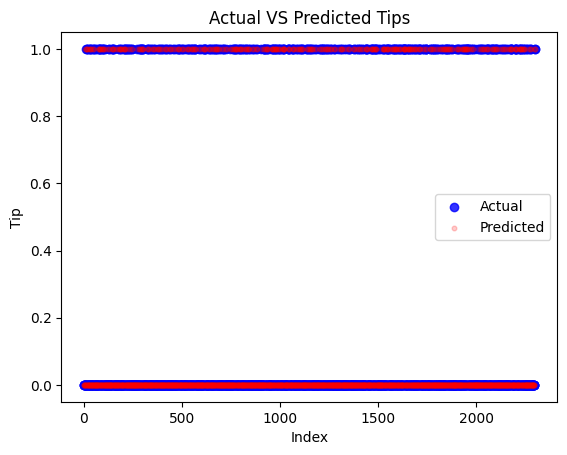

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1839
           1       0.86      0.83      0.85       461

    accuracy                           0.94      2300
   macro avg       0.91      0.90      0.90      2300
weighted avg       0.94      0.94      0.94      2300



In [ ]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, Y_train)
y_pred_dt = clf.predict(X_test)
acc_dt = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_dt) + ' %')
confusion = confusion_matrix(Y_test, y_pred_dt , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_dt)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("Decision Tree Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_dt})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=11.2)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_dt))

100.0 %


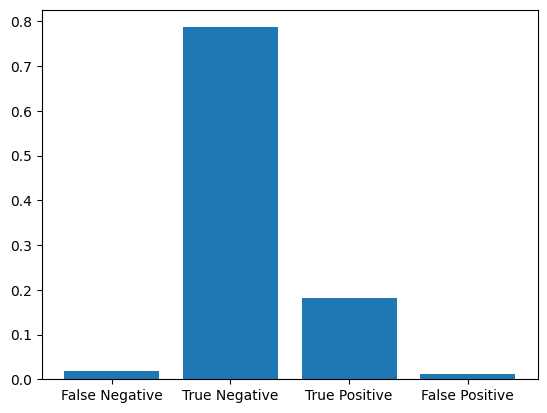

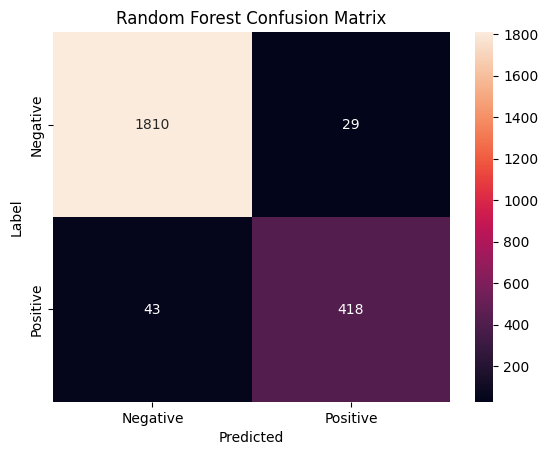

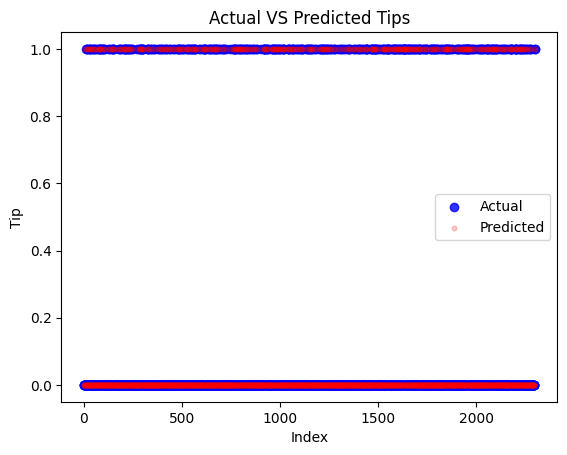

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1839
           1       0.94      0.91      0.92       461

    accuracy                           0.97      2300
   macro avg       0.96      0.95      0.95      2300
weighted avg       0.97      0.97      0.97      2300



In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, Y_train)
y_pred_rf = clf.predict(X_test)
acc_rf = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_rf) + ' %')
confusion = confusion_matrix(Y_test, y_pred_rf , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_rf)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("Random Forest Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_rf})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=11.3)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_rf))

100.0 %


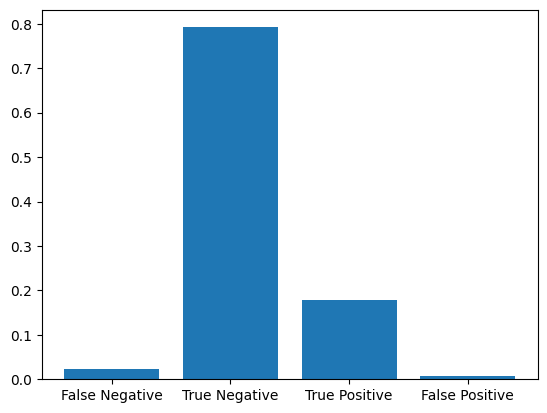

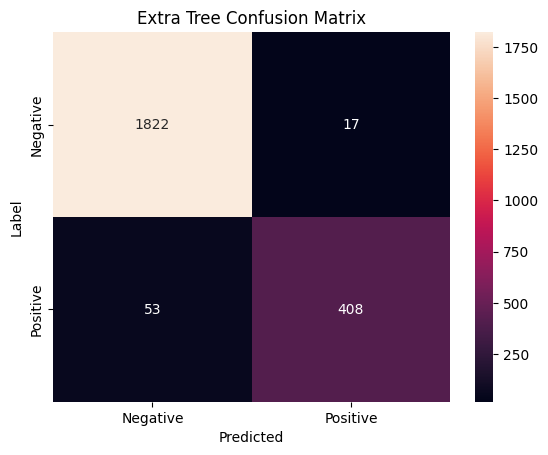

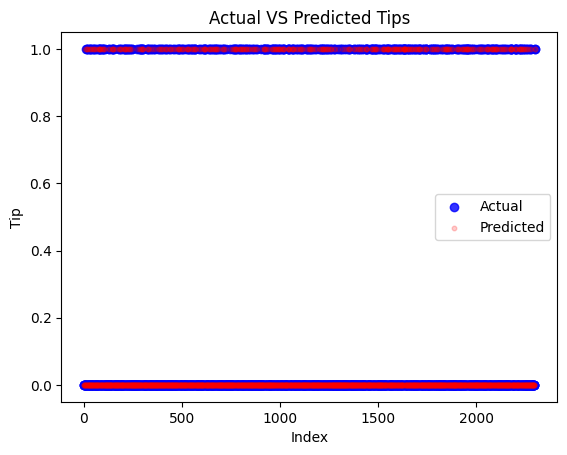

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1839
           1       0.96      0.89      0.92       461

    accuracy                           0.97      2300
   macro avg       0.97      0.94      0.95      2300
weighted avg       0.97      0.97      0.97      2300



In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import ExtraTreesClassifier
clf = ExtraTreesClassifier()
clf.fit(X_train, Y_train)
y_pred_et = clf.predict(X_test)
acc_et = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_et) + ' %')
confusion = confusion_matrix(Y_test, y_pred_et , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_et)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("Extra Tree Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_et})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=10.9)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_et))

94.15 %


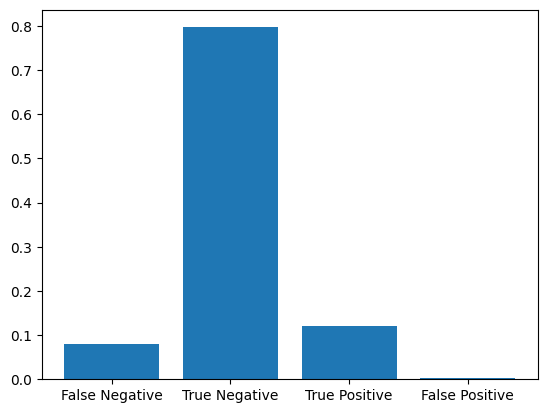

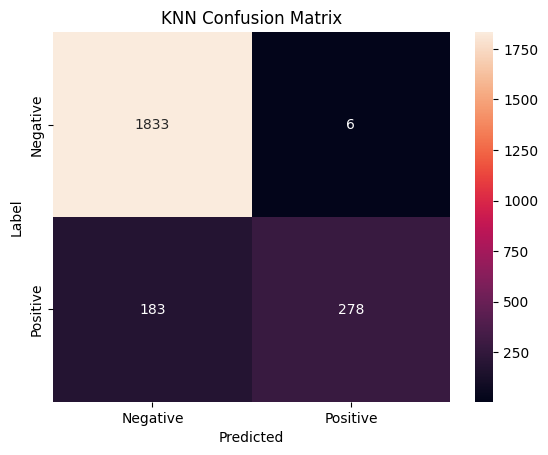

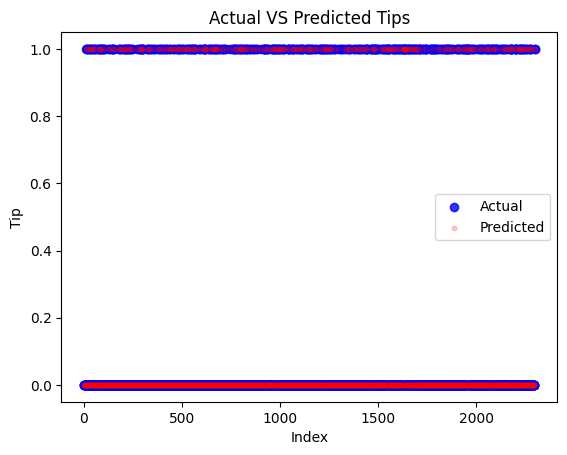

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1839
           1       0.98      0.60      0.75       461

    accuracy                           0.92      2300
   macro avg       0.94      0.80      0.85      2300
weighted avg       0.92      0.92      0.91      2300



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
k = 5
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X_train, Y_train)
y_pred_knn = clf.predict(X_test)
acc_knn = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_knn) + ' %')
confusion = confusion_matrix(Y_test, y_pred_knn , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_knn)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("KNN Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_knn})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=10.5)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_knn))

In [ ]:
#Importing keras libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(activation = 'relu',units=10))

In [ ]:
classifier.add(Dense(units=10, activation = 'relu'))

In [ ]:
classifier.add(Dense(units=10, activation = 'sigmoid'))

In [ ]:
classifier.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

#Fitting the ANN to the training set
classifier.fit(X_train, Y_train, batch_size = 10, epochs = 100)

Epoch 1/100
920/920 [==============================] - 10s 7ms/step - loss: 0.6854 - accuracy: 0.8672
Epoch 2/100
920/920 [==============================] - 8s 8ms/step - loss: 0.1612 - accuracy: 0.9512
Epoch 3/100
920/920 [==============================] - 5s 6ms/step - loss: 0.1297 - accuracy: 0.9599
Epoch 4/100
920/920 [==============================] - 4s 4ms/step - loss: 0.1106 - accuracy: 0.9627
Epoch 5/100
920/920 [==============================] - 7s 7ms/step - loss: 0.1011 - accuracy: 0.9658
Epoch 6/100
920/920 [==============================] - 5s 5ms/step - loss: 0.0911 - accuracy: 0.9690
Epoch 7/100
920/920 [==============================] - 2s 3ms/step - loss: 0.0857 - accuracy: 0.9713
Epoch 8/100
920/920 [==============================] - 3s 3ms/step - loss: 0.0799 - accuracy: 0.9727
Epoch 9/100
920/920 [==============================] - 3s 4ms/step - loss: 0.0758 - accuracy: 0.9732
Epoch 10/100
920/920 [==============================] - 3s 4ms/step - loss: 0.0738 - accur

100.0%


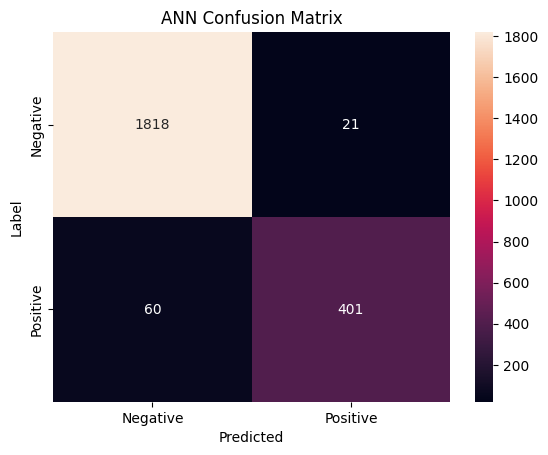

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1839
           1       0.95      0.87      0.91       461

    accuracy                           0.96      2300
   macro avg       0.96      0.93      0.94      2300
weighted avg       0.96      0.96      0.96      2300



In [ ]:
# Predicting the Test set results
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier()
clf.fit(X_train, Y_train)
y_pred_ann = clf.predict(X_test)
acc_ANN = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_ANN) + '%')
confusion = confusion_matrix(Y_test, y_pred_ann)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.title("ANN Confusion Matrix")
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.show()
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred_ann))
#spe_ANN=98.12
#sen_ANN=90.36

98.23 %


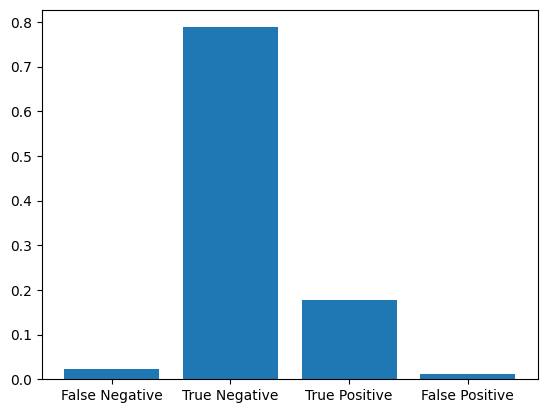

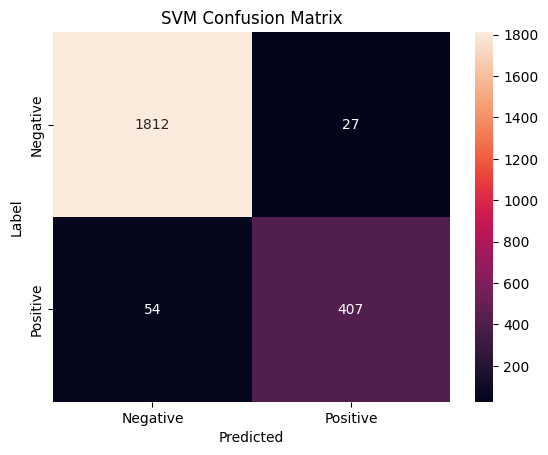

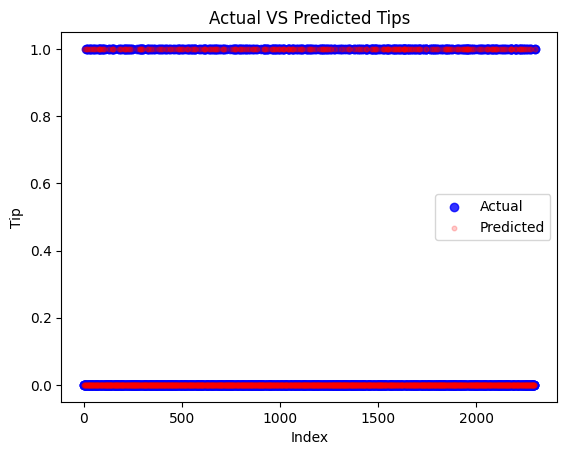

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1839
           1       0.94      0.88      0.91       461

    accuracy                           0.96      2300
   macro avg       0.95      0.93      0.94      2300
weighted avg       0.96      0.96      0.96      2300



In [ ]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
clf = SVC()
clf.fit(X_train, Y_train)
y_pred_svm = clf.predict(X_test)
acc_svm = round(clf.score(X_train, Y_train) * 100, 2)
print (str(acc_svm) + ' %')
confusion = confusion_matrix(Y_test, y_pred_svm , normalize= 'all')
FN = confusion[1][0]
TN = confusion[0][0]
TP = confusion[1][1]
FP = confusion[0][1]
plt.bar(['False Negative' , 'True Negative' , 'True Positive' , 'False Positive'],[FN,TN,TP,FP])
plt.show()
confusion = confusion_matrix(Y_test, y_pred_svm)
sns.heatmap(confusion, fmt='g',annot=True , xticklabels=['Negative' , 'Positive'] , yticklabels=['Negative' , 'Positive'])
plt.ylabel("Label")
plt.xlabel("Predicted")
plt.title("SVM Confusion Matrix")
plt.show()
#spe_log_reg= 99.94
#sen_log_reg=7.11
df_results = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_svm})
plt.figure()
plt.scatter(df_results.index,df_results['Actual'],color='blue',label='Actual',alpha=0.8)
plt.scatter(df_results.index,df_results['Predicted'],color='red',label='Predicted',alpha=0.2,s=11.1)
plt.xlabel('Index')
plt.ylabel('Tip')
plt.legend()
plt.title('Actual VS Predicted Tips')
plt.show()
print(classification_report(Y_test,y_pred_svm))

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
acc_PCA = round(pca.score(X_train, Y_train) )
print (str(acc_PCA) + '%')

89%


Text(0, 0.5, 'accuracy(%)')

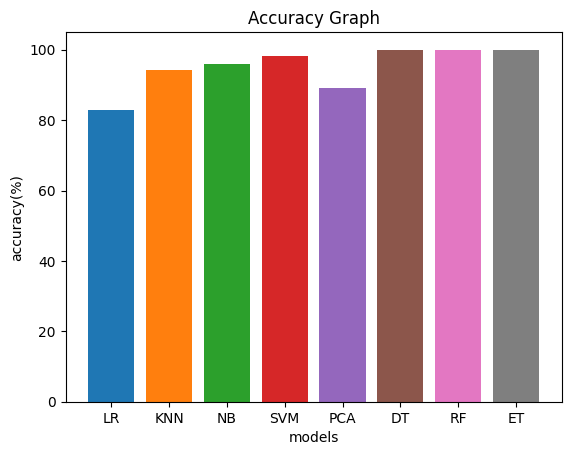

In [ ]:
models = pd.DataFrame({
    'Model': [{'Logistic Regression': acc_log_reg}, {'KNN': acc_knn},{'Naive Bayes': acc_nb},{'Support Vector Machines': acc_svm},{'Principal Component Analysis': acc_PCA},{'Decision Tree':acc_dt},{'Random Forest':acc_rf},{'Extra tree':acc_et}]})
models.Model
plt.bar("LR", models.Model[0]["Logistic Regression"])
plt.bar("KNN", models.Model[1]["KNN"])
plt.bar("NB", models.Model[2]["Naive Bayes"])
plt.bar("SVM", models.Model[3]["Support Vector Machines"])
plt.bar("PCA", models.Model[4]["Principal Component Analysis"])
plt.bar("DT", models.Model[5]["Decision Tree"])
plt.bar("RF", models.Model[6]["Random Forest"])
plt.bar("ET", models.Model[7]["Extra tree"])
plt.title("Accuracy Graph")
plt.xlabel("models")
plt.ylabel("accuracy(%)")

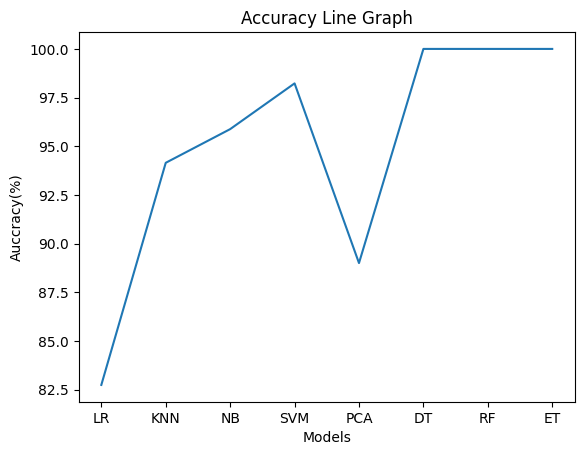

In [ ]:
models.Model
names = ["LR", 'KNN','NB',"SVM", 'PCA',"DT","RF","ET"]
values = [models.Model[0]["Logistic Regression"], models.Model[1]["KNN"],models.Model[2]["Naive Bayes"],models.Model[3]["Support Vector Machines"],models.Model[4]["Principal Component Analysis"],models.Model[5]["Decision Tree"],models.Model[6]["Random Forest"],models.Model[7]["Extra tree"]]
plt.xlabel("Models")
plt.ylabel("Auccracy(%)")
plt.title("Accuracy Line Graph")
plt.plot(names, values)
plt.show()